# Assignment 7
### Do any five (I did 1,2,4,8,9).

## 1. 

- What is the expected value of a single die roll? 
- What is the expected value of rolling two dice and adding the results together?
- What is the expected winnings of any gamble in European roulette?

- Imagine you roll a die, and you record the value you get. But, if you roll a six, you roll again, and add that value. What is the expected value?
- Imagine that the process described in the last question continues until you fail to roll a six. What is the expected value of the process? (This can be tricky, you can simulate it to get an answer if you prefer. Hint: The answer is 4.2.)

In [1]:
# expected value of a single dice roll
import pandas as pd
import numpy as np
import random
E_single = np.mean([1, 2, 3, 4, 5, 6])
print("Single die (formula):", E_single)

Single die (formula): 3.5


In [2]:
# 2. Expected value of two dice (formula)
E_two_dice = E_single * 2
print("Two dice (formula):", E_two_dice)

Two dice (formula): 7.0


In [3]:
# 3 what is the expected winning for european roulette
# E = payout X winning prob - bet X losing prob ((37 - K)/37)

E_roulette = 36/37 -1 
print("Roulette EV (per $1 bet):", E_roulette)

Roulette EV (per $1 bet): -0.027027027027026973


In [4]:
#4 Imagine you roll a die, and you record the value you get. But, if you roll a six, you roll again, and add that value. What is the expected value?
def roll_extra_if_six():
    r = random.randint(1, 6)
    if r == 6:
        return 6 + random.randint(1, 6)
    return r

N = 1_000_000
sim_once = [roll_extra_if_six() for i in range(N)]
print("One extra roll if 6 (simulation):", np.mean(sim_once))

# theoretical value
print("One extra roll if 6 (theoretical):", 4.2)

One extra roll if 6 (simulation): 4.076909
One extra roll if 6 (theoretical): 4.2


In [5]:
# Imagine that the process described in the last question continues until you fail to roll a six. What is the expected value of the process? (This can be tricky, you can simulate it to get an answer if you prefer. Hint: The answer is 4.2.)

def roll_until_not_six():
    total = 0
    while True:
        r = random.randint(1, 6)
        total += r
        if r != 6:
            break
    return total

sim_full = [roll_until_not_six() for i in range(N)]
print("Full recurring process (simulation):", np.mean(sim_full))
print("Full recurrring process (theoretical):", 4.2)


Full recurring process (simulation): 4.195104
Full recurrring process (theoretical): 4.2


So in expectation, it goes from below 3 to around 4.2 for the whole continuous process as we run the simulation

## 2. 
- Compute the expected value for a uniform random variable.
- Show that $\mathbb{E}[a+bX] = a + b\mathbb{E}[X]$
- Show, by example, that $v(\mathbb{E}[X]) \neq \mathbb{E}[v(X)]$, if $v(x) \neq a+bx$. For example, try $v(y) = y^2$ or $v(y)=\sqrt{y}$ with a Bernoulli or uniform or normally distributed random variable. This can be an important thing to remember: The expectation of a transformed random variable is not the transformation of the expected value.



### Expected value of a Uniform(0,1)

For a continuous uniform distribution over $[0,1]$, the density is constant at 1.  
So the mean is simply:

$$
\mathbb{E}[X]
= \int_0^1 x\, dx
= \left[\frac{x^2}{2}\right]_0^1
= \frac{1}{2}.
$$


### Showing that $\mathbb{E}[a + bX] = a + b\,\mathbb{E}[X]$

Start with the definition:

$$
\mathbb{E}[a + bX]
= \int_{-\infty}^{\infty} (a + bx)\, f(x)\, dx.
$$

Break the integral into two simpler parts:

$$
\mathbb{E}[a + bX]
= a \int_{-\infty}^{\infty} f(x)\, dx
\;+\;
b \int_{-\infty}^{\infty} x\, f(x)\, dx.
$$

Because every valid pdf integrates to 1:

$$
\int_{-\infty}^{\infty} f(x)\, dx = 1,
$$

I obtain:

$$
\mathbb{E}[a + bX] = a + b\,\mathbb{E}[X].
$$


### Example where $v(\mathbb{E}[X]) \neq \mathbb{E}[v(X)]$

Take $X \sim \text{Uniform}(0,1)$ and choose a nonlinear function such as $v(x) = \sqrt{x}$.

Here, I compute the function evaluated at the mean:

$$
v(\mathbb{E}[X])
= \sqrt{\frac{1}{2}}
= \frac{1}{\sqrt{2}}.
$$

Now I compute the expected value of the transformed variable:

$$
\mathbb{E}[\sqrt{X}]
= \int_0^1 \sqrt{x}\, dx
= \left[\frac{2}{3} x^{3/2}\right]_0^1
= \frac{2}{3}.
$$

Since
$$
\frac{1}{\sqrt{2}} \neq \frac{2}{3},
$$
this shows that, in general, nonlinear transformations do **not** commute with expectation.


Expected Value: 0.6676787044223342
Value of Expectation: 0.7079139638172595


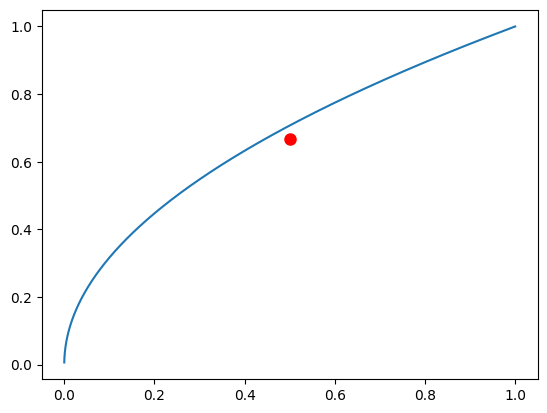

In [6]:
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

def v(x):
    return np.sqrt(x)

sample = np.random.uniform(low=0, high=1,size = 20000)

Ev_of_sample = np.mean( v(sample) )
print(f'Expected Value: {Ev_of_sample}')

v_of_EX = v(np.mean(sample))
print(f'Value of Expectation: {v_of_EX}')

sns.lineplot(x=sample, y=v(sample))
plt.plot(np.mean(sample),Ev_of_sample, 'o', color='red', markersize=8)

Based off my analysis 
$$
\frac{1}{\sqrt{2}} (.70) \neq \frac{2}{3} (.66)
$$

This means that the expected value doesn't match the value of expectation

## 3. 
- Compute the variance for a uniform random variable.
- Show that 
$$
\mathbb{V}[X] = \mathbb{E}[X^2] - \mathbb{E}[X]^2
$$
$$
\mathbb{V}[a+bX] = b^2 \mathbb{V}[X]
$$
- Show that if $X$ is a normally distributed random variable, then $a + bX$ is distributed normally with mean $a+ b \mathbb{E}[X]$ and variance $b^2 \sigma_X^2$ 

These properties get used all the time!


## 4.

- The **covariance** of $X$ and $Y$ is
$$
\text{cov}(X,Y) = \int_{y} \int_{x} (x-\mathbb{E}[X])(y-\mathbb{E}[Y])f_{XY}(x,y) dxdy = \mathbb{E}_{XY}[ (x-\mu_X)(y-\mu_Y)]
$$
- Show that if $f_{XY}(x,y)=f_X(x)f_Y(y)$, then $\text{cov}(X,Y)=0$
- Provide an example (computation/simulation is fine) where $\text{cov}(X,Y)\approx 0$ but $f_{XY}(x,y)\neq 0$
- The covariance doesn't characterize joint random variables except in a few special cases: The covariance only captures the **linear** association between the two variables, not nonlinear associations.

### Covariance Definition

For two continuous random variables $X$ and $Y$ with joint density $f_{XY}(x,y)$, the covariance is

$$
\mathrm{cov}(X,Y)
= \int\!\!\int (x - \mathbb{E}[X])(y - \mathbb{E}[Y]) \, f_{XY}(x,y)\, dx\, dy.
$$

Equivalently,

$$
\mathrm{cov}(X,Y)=\mathbb{E}[(X-\mu_X)(Y-\mu_Y)].
$$


### Showing that independence implies zero covariance

If $X$ and $Y$ are independent, then the joint factorizes:

$$
f_{XY}(x,y)=f_X(x)f_Y(y).
$$

Plugging this into the covariance integral, I get

$$
\mathrm{cov}(X,Y)
= \int\!\!\int (x-\mu_X)(y-\mu_Y) f_X(x) f_Y(y)\, dx\, dy.
$$

Here, I  separate the integrals:

$$
\mathrm{cov}(X,Y)
= \left[\int (x-\mu_X) f_X(x)\, dx\right]
  \left[\int (y-\mu_Y) f_Y(y)\, dy\right].
$$

But each bracket is zero, because

$$
\int (x-\mu_X) f_X(x)\, dx = \mathbb{E}[X] - \mathbb{E}[X] = 0,
$$

and similarly for $Y$. This means that

$$
\mathrm{cov}(X,Y)=0.
$$


### Example where covariance is zero but dependence exists

Covariance only detects **linear** relationships. A nonlinear dependence can still yield covariance zero.

A simple example is:

$$
Y = |X| + \sigma \varepsilon,
$$

where

- $X \sim N(0,1)$, where $X$ is a random variable with normal distribution 
- $\varepsilon \sim N(0,1)$ noise that is independent of $X$,
- $\sigma > 0$. this is basically a scaling constant in terms of STD

Then $\mathbb{E}[X] = 0$, and $Y$ depends on $X$ through $|X|$, but the odd symmetry of $X$ makes

$$
\mathbb{E}[XY] = 0, \qquad \mathrm{cov}(X,Y)=0,
$$

even though $X$ and $Y$ are not independent.



## 5. 

Suppose $X$ has an expectation $\mathbb{E}[X]<\infty$ and variance $\mathbb{V}[X]<\infty$; this isn't always true, but is *usually* true
- Consider making a new variable, $\varepsilon = X - \mathbb{E}[X]$
- What's the expectation of $\varepsilon$?
- What's the variance of $\varepsilon$?
- So we can write any random variable in the form $X = \mathbb{E}[X] + \varepsilon, $ where $\mathbb{E}[\varepsilon]=0$ and $\mathbb{V}[\varepsilon] = \sigma_X^2$
- If that's true, show that we can also write any random variable in the form $X = \mathbb{E}[X] + \sigma_X \varepsilon$, where $\mathbb{E}[\varepsilon]=0$ and $\mathbb{V}[\varepsilon]=1$
- Now replace $\mathbb{E}[X]$ with $x\beta$, and the stage is set for regression models

## 6.
- Use the Taylor series expansions 
$$
F(x+h) = F(x) + hf(x) + \frac{h^2}{2}f'(x) + O(h^3)
$$ 
and 
$$
F(x-h) = F(x) - h f(x) + \frac{h^2}{2} f'(x)+ O(h^3)
$$
to show that
$$
\mathbb{E}[\hat{f}_{X,h}(x)] = \frac{F(x+h)-F(x-h)}{2h} = f(x) + O(h^2),
$$
so the **bias** of the KDE is $O(h^2)$, unlike the ECDF, for which $\mathbb{E}[\hat{F}(x)] = F(x)$.

## 7.
- Suppose $X$ and $Y$ are distributed bivariate normal. Show that if $\rho=0$, then $X$ and $Y$ are independent.
- For the multivariate normal, show that if $\Sigma$ is a diagonal matrix, then $X_1, X_2, ..., X_n$ are independent.
- For the multivariate normal, show that if $\Sigma$ is a diagonal matrix and all the $\sigma_i^2$ and all the $\mu_i$ are equal, then $X_1, X_2, ..., X_n$ are independently distributed random variables with distribution $N(\mu, \sigma^2)$

## 8.
- Open the METABRIC data. Make a histogram of 'Ratio Therapy'.
- Let treatment, $T$ be distributed binomial with parameter $p$. Then the contribution to the likelihood for each patient $i$, with $y_i = 0$ for no radiation therapy and $y_i=1$ for radiation therapy, is 
$$
p^{y_i}(1-p)^{1-y_i}
$$
- Write out the likelihood.
- Maximize the likelihood with respect to $p$. What is the MLE, $\hat{p}$?
- Bootstrap the sampling density/distribution of $\hat{p}$.

<Axes: xlabel='Radio Therapy', ylabel='Proportion'>

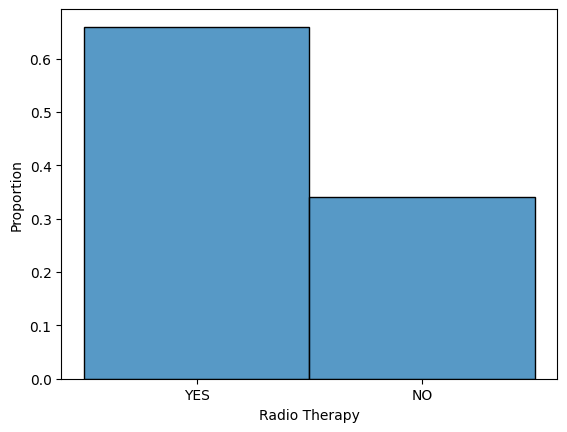

In [7]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy as sp 

Metabric = pd.read_csv('./data/metabric.csv')

y = Metabric['Radio Therapy']
sns.histplot(y,stat='proportion')

### Likelihood and MLE for a Bernoulli Model

For data $y_1,\ldots,y_n$ with each $y_i \in \{0,1\}$, the Bernoulli likelihood is

$$
L(p) = \prod_{i=1}^n p^{\,y_i}(1-p)^{\,1-y_i}.
$$

Taking logs:

$$
\ell(p)
= \sum_{i=1}^n \left[ y_i \log p + (1-y_i)\log(1-p) \right].
$$

Here I Differentiate:

$$
\ell'(p)
= \sum_{i=1}^n \left( \frac{y_i}{p} - \frac{1-y_i}{1-p} \right).
$$

The MLE satisfies $\ell'(p)=0$:

$$
\sum_{i=1}^n \frac{y_i}{\hat{p}}
\;=\;
\sum_{i=1}^n \frac{1-y_i}{1-\hat{p}}.
$$

Solving gives the familiar estimator, I get the following:

$$
\hat{p}
= \frac{1}{n} \sum_{i=1}^n y_i,
$$

the sample proportion of ones.


/tmp/ipykernel_656/2989874792.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y.replace({'NO': 0, 'YES': 1}),


MLE estimate: 0.659717051377513


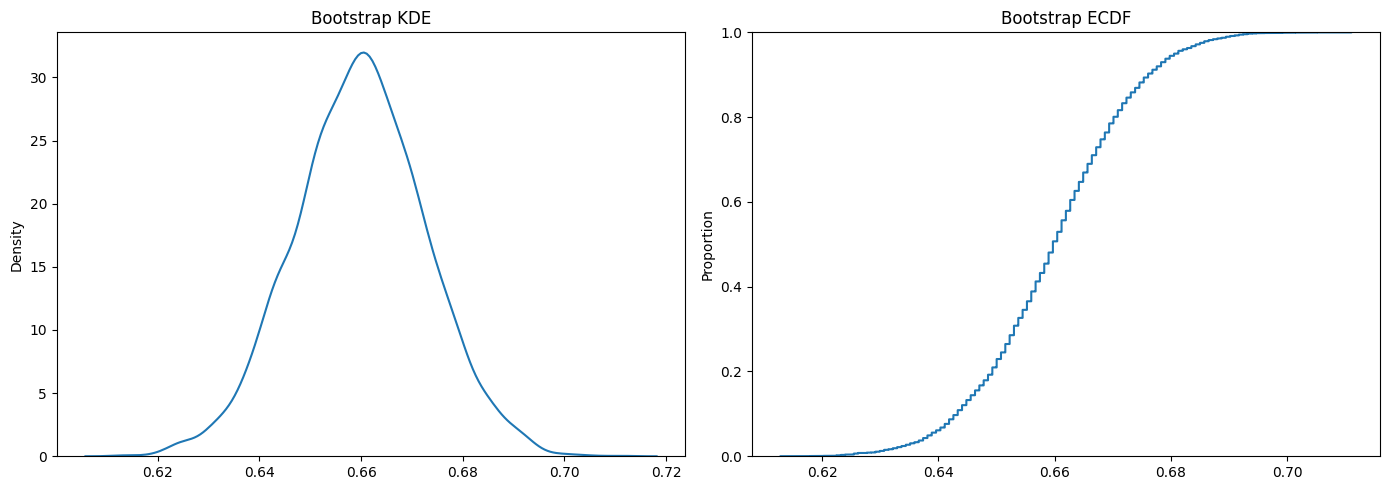

In [8]:
y_num = pd.to_numeric(
    y.replace({'NO': 0, 'YES': 1}),
    errors='coerce'
)


print("MLE estimate:", y_num.mean())

# Bootstrap simulation
B = 5000
boot_vals = [y_num.sample(n=len(y_num), replace=True).mean() for _ in range(B)]

# Here I Plot KDE and ECDF
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(boot_vals, ax=ax[0])
ax[0].set_title("Bootstrap KDE")

sns.ecdfplot(boot_vals, ax=ax[1])
ax[1].set_title("Bootstrap ECDF")

plt.tight_layout()
plt.show()


## 9.
- Open the Ames house price data. Make a KDE of 'price'. Select an appropriate distribution for modeling it, and explain why you selected it. (Hint: You might want to take a common transformation of price.)
- Derive the density for this distribution.
- Write out the likelihood.
- Maximize the likelihood. What is the MLE?
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of your parameters.

<Axes: xlabel='price', ylabel='Proportion'>

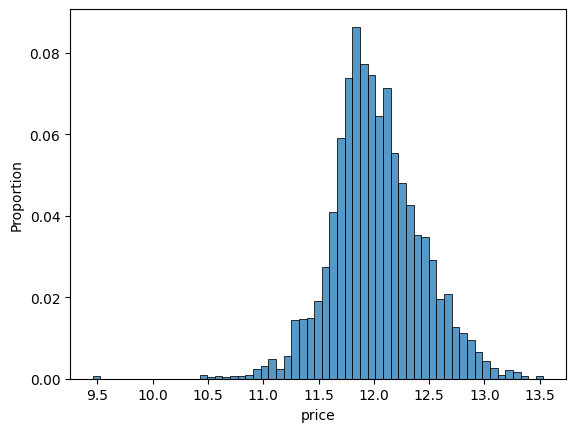

In [9]:
df = pd.read_csv('./data/ames_prices.csv')
y = np.log( df['price'] )
sns.histplot(y,stat='proportion')

### Normal Density and Likelihood

For observations $y_1,\dots,y_n$ assumed i.i.d. from a Normal$(\mu,\sigma)$ distribution, the density is

$$
f(y) = \frac{1}{\sqrt{2\pi}\,\sigma}\exp\!\left[-\frac{1}{2}\left(\frac{y-\mu}{\sigma}\right)^2\right].
$$

The likelihood for the full sample is

$$
L(\mu,\sigma)
= \prod_{i=1}^n \frac{1}{\sqrt{2\pi}\,\sigma}
\exp\!\left[-\frac{1}{2}\left(\frac{y_i-\mu}{\sigma}\right)^2\right].
$$

Here I take the logs gives the log-likelihood:

$$
\ell(\mu,\sigma)
= -n\log(\sigma) - \frac{1}{2\sigma^2}\sum_{i=1}^n (y_i - \mu)^2 - \frac{n}{2}\log(2\pi).
$$

Differentiate with respect to $\mu$ and $\sigma$:

$$
\frac{\partial \ell}{\partial \mu}
= \frac{1}{\sigma^2}\sum_{i=1}^n (y_i - \mu),
$$

$$
\frac{\partial \ell}{\partial \sigma}
= -\frac{n}{\sigma} + \frac{1}{\sigma^3}\sum_{i=1}^n (y_i - \mu)^2.
$$

Setting both equal to zero, Here I yield the MLEs:

$$
\hat{\mu} = \frac{1}{n}\sum_{i=1}^n y_i,
$$

$$
\hat{\sigma}
= \sqrt{\frac{1}{n}\sum_{i=1}^n (y_i - \hat{\mu})^2}.
$$


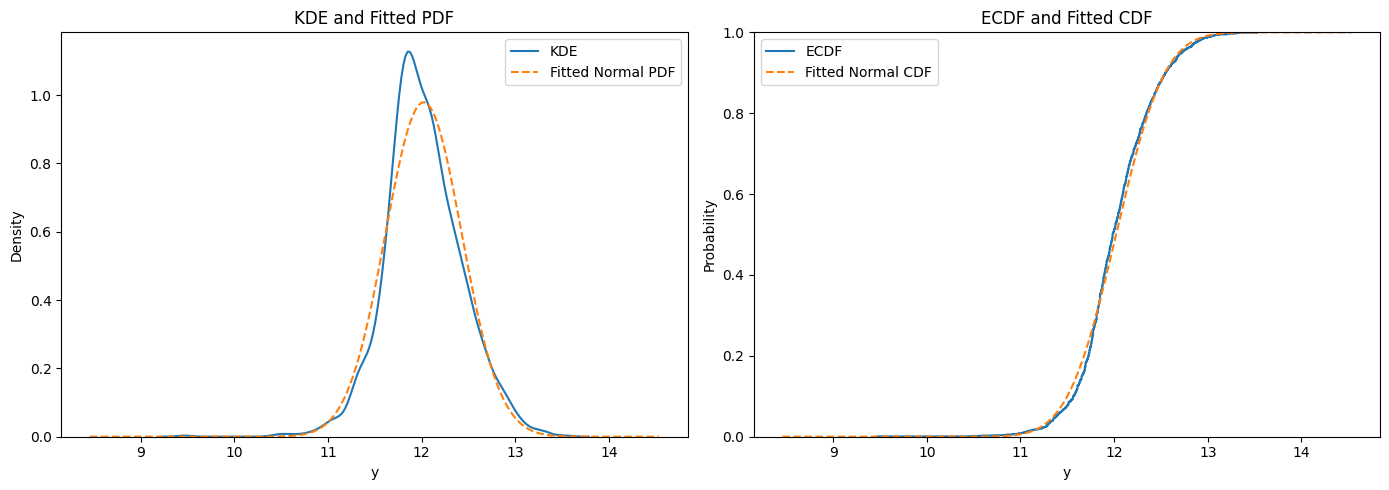

In [10]:

mu_hat = y.mean()
sigma_hat = np.sqrt(((y - mu_hat) ** 2).mean())


x_grid = np.linspace(y.min() - 1, y.max() + 1, 200)


pdf_fit = sp.stats.norm.pdf(x_grid, loc=mu_hat, scale=sigma_hat)
cdf_fit = sp.stats.norm.cdf(x_grid, loc=mu_hat, scale=sigma_hat)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE vs fitted pdf
sns.kdeplot(y, ax=axes[0], label="KDE")
axes[0].plot(x_grid, pdf_fit, linestyle="--", label="Fitted Normal PDF")
axes[0].set_title("KDE and Fitted PDF")
axes[0].set_xlabel("y")
axes[0].set_ylabel("Density")
axes[0].legend()

#  ECDF vs fitted cdf
sns.ecdfplot(y, ax=axes[1], label="ECDF")
axes[1].plot(x_grid, cdf_fit, linestyle="--", label="Fitted Normal CDF")
axes[1].set_title("ECDF and Fitted CDF")
axes[1].set_xlabel("y")
axes[1].set_ylabel("Probability")
axes[1].legend()

plt.tight_layout()
plt.show()


The fit of the ECDF are good. The lines are right on top of one another which means the KDE capture the underlying distribution of the PDF. Overall, more testing needs to be done (such as a QQ plot), but everything else seems fine

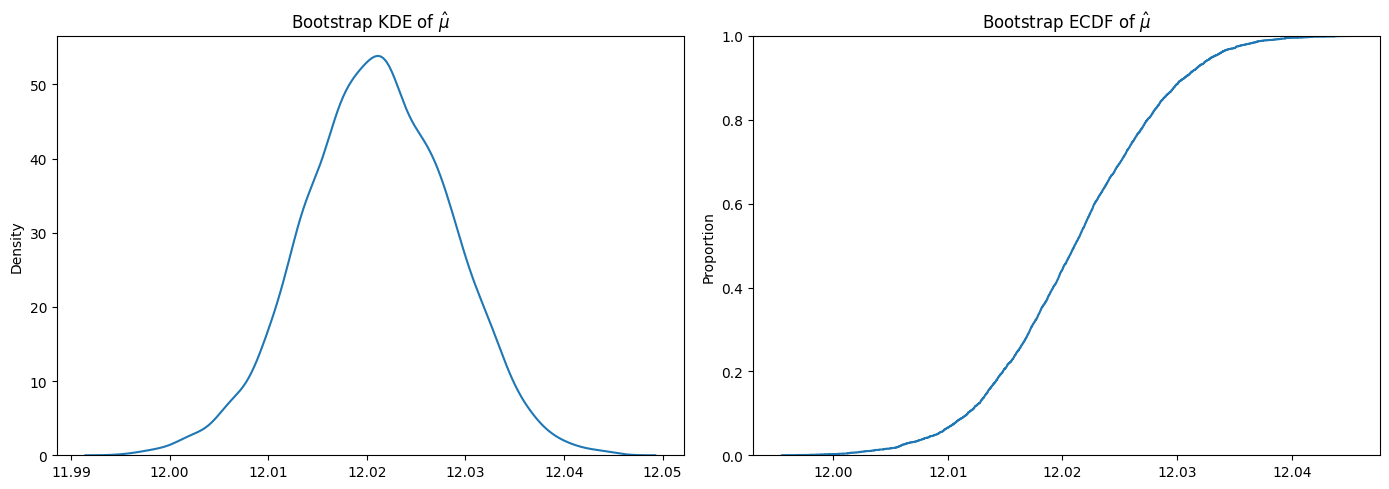

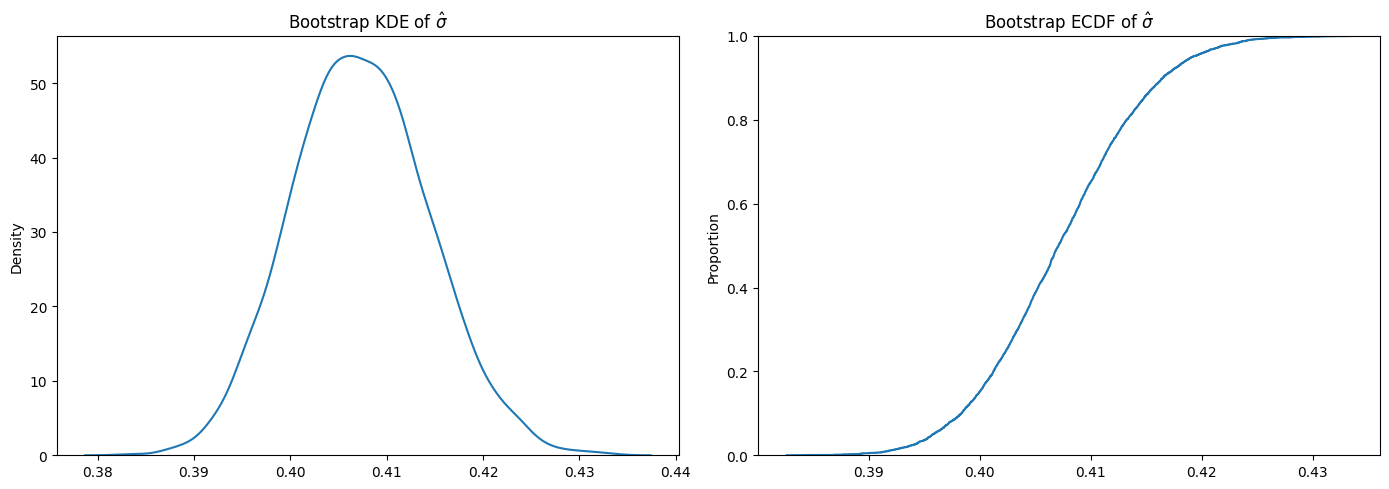

In [11]:
# This is the MLE estimation function
def estimate_params(values):
    mu = values.mean()
    sigma = np.sqrt(((values - mu) ** 2).mean())
    return mu, sigma

# Here I boostrap for sample size of 5000
B = 5000
boot_results = [
    estimate_params(y.sample(n=len(y), replace=True))
    for _ in range(B)
]

# This the boostrap for mu (mean) and sigma (std dev)
boot_mu = [res[0] for res in boot_results]
boot_sigma = [res[1] for res in boot_results]

# mu (mean)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(boot_mu, ax=ax[0])
ax[0].set_title("Bootstrap KDE of $\hat{\mu}$")

sns.ecdfplot(boot_mu, ax=ax[1])
ax[1].set_title("Bootstrap ECDF of $\hat{\mu}$")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(boot_sigma, ax=ax[0])
ax[0].set_title("Bootstrap KDE of $\hat{\sigma}$")

sns.ecdfplot(boot_sigma, ax=ax[1])
ax[1].set_title("Bootstrap ECDF of $\hat{\sigma}$")

plt.tight_layout()
plt.show()


## 10.
- Open the METABRIC data. Make a KDE of 'Overall Survival (Months)'.
- Let survival time, $T$ be distributed exponentially with parameter $\lambda$. Then its distribution is
$$
F(t) = 1 - e^{-\lambda t} = p[T\le t].
$$
- Derive the density for this distribution.
- Write out the likelihood.
- Maximize the likelihood with respect to $\lambda$. What is the MLE, $\hat{\lambda}$?
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of $\hat{\lambda}$.

## 11.
- Open the Ames house price data. Make a histogram of 'TotRms.AbvGrd', or total rooms above ground.
- We're going to model this using the Poisson Distribution. The probability that $y_i = k$ is given by
$$
pr[y_i = k ] = \frac{ \lambda^k e^{-\lambda} }{k!}
$$
- Write out the likelihood.
- Maximize the likelihood. What is the MLE? (Hint: The sample mean. As usual.)
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of your parameter.

## 12.
- Open the METABRIC data. Make a histogram of 'Mutation Count' with around 50 bins. Let $Y$ be the mutation count the random variable, and $y_i$ the mutation count for patient $i$.
- We're going to model this using the Poisson Distribution. The probability that $y_i = k$ is given by
$$
pr[y_i = k ] = \frac{ \lambda^k e^{-\lambda} }{k!}
$$
- Write out the likelihood.
- Maximize the likelihood. What is the MLE? (Hint: The sample mean. As usual.)
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of your parameter.